In [2]:
import pandas as pd
college = pd.read_csv(r'C:\Users\selvi\OneDrive\Desktop\project_ppm\collegePlace.csv')

In [3]:
college.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [4]:
college.shape

(2966, 8)

In [5]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2966 non-null   int64 
 1   Gender             2966 non-null   object
 2   Stream             2966 non-null   object
 3   Internships        2966 non-null   int64 
 4   CGPA               2966 non-null   int64 
 5   Hostel             2966 non-null   int64 
 6   HistoryOfBacklogs  2966 non-null   int64 
 7   PlacedOrNot        2966 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 185.5+ KB


In [6]:
college.isnull().sum()

Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
HistoryOfBacklogs    0
PlacedOrNot          0
dtype: int64

In [7]:
college.columns

Index(['Age', 'Gender', 'Stream', 'Internships', 'CGPA', 'Hostel',
       'HistoryOfBacklogs', 'PlacedOrNot'],
      dtype='object')

In [8]:
college.nunique()

Age                  11
Gender                2
Stream                6
Internships           4
CGPA                  5
Hostel                2
HistoryOfBacklogs     2
PlacedOrNot           2
dtype: int64

In [9]:
college.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [10]:
college.describe()

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
count,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000
mean,21.485840,0.703641,7.073837,0.269049,0.192178,0.552596
std,1.324933,0.740197,0.967748,0.443540,0.394079,0.497310
min,19.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,6.000000,0.000000,0.000000,0.000000
50%,21.000000,1.000000,7.000000,0.000000,0.000000,1.000000
75%,22.000000,1.000000,8.000000,1.000000,0.000000,1.000000
max,30.000000,3.000000,9.000000,1.000000,1.000000,1.000000


In [11]:
# calculating placement percentage
placed_number = (college['PlacedOrNot'] == 1).sum()
notplaced_number = (college['PlacedOrNot'] == 0).sum()

In [12]:
placed_percent = ((placed_number/len(college)) * 100)

In [13]:
print(f'The placement percentage is {placed_percent:.2f}')

The placement percentage is 55.26


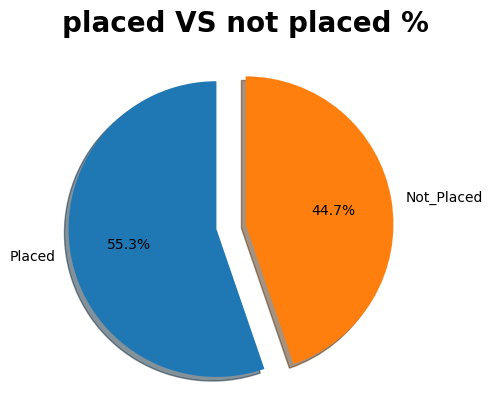

In [14]:
import matplotlib.pyplot as plt
category = ['Placed','Not_Placed']
plt.pie(college['PlacedOrNot'].value_counts(),
        labels = category,
        autopct = '%1.1f%%',
        shadow=True,
        explode=[0.2,0],
        startangle=90
        )
plt.title('placed VS not placed %',
          fontsize = 20,
          fontweight = 'bold')
plt.show()

In [15]:
college.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [16]:

avg_cgpa = college.groupby('PlacedOrNot').agg({'CGPA' : 'mean'}).round(2)

In [17]:
avg_cgpa.index.tolist()

[0, 1]

In [18]:
avg_cgpa.columns

Index(['CGPA'], dtype='object')

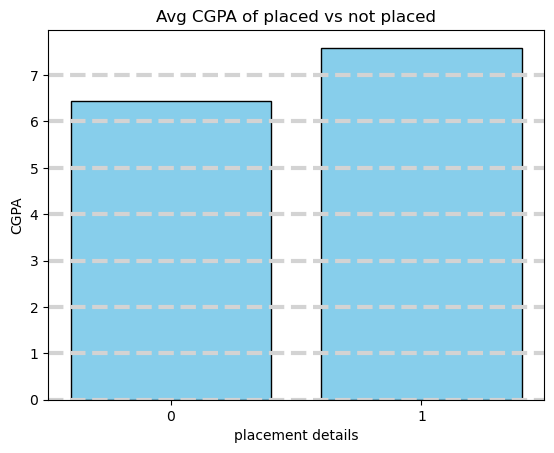

In [19]:
plt.bar(avg_cgpa.index,avg_cgpa['CGPA'],
        color = 'skyblue',
        edgecolor = 'black')
plt.grid(axis = 'y',linewidth = 3,
         linestyle = 'dashed',
         color = 'lightgray')
plt.xticks(avg_cgpa.index)
plt.title('Avg CGPA of placed vs not placed')
plt.xlabel('placement details')
plt.ylabel('CGPA')
plt.show()


In [20]:
college.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [21]:
stream_place = college.groupby('Stream').agg({'PlacedOrNot':'mean'})

In [22]:
stream_place = (stream_place * 100).round(2)

In [23]:
print(stream_place)

                               PlacedOrNot
Stream                                    
Civil                                46.06
Computer Science                     58.25
Electrical                           54.19
Electronics And Communication        59.20
Information Technology               59.19
Mechanical                           47.17


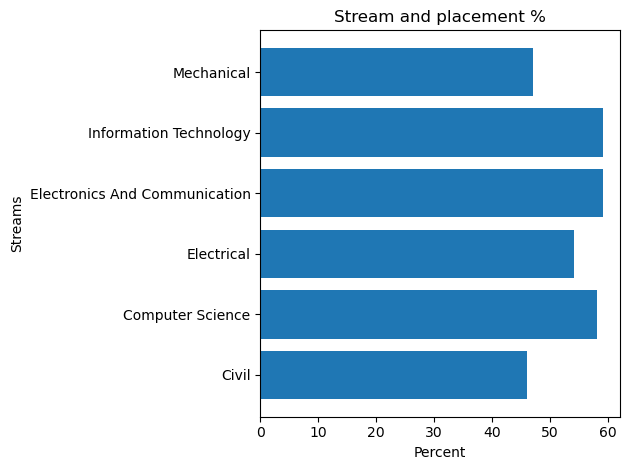

In [24]:
plt.barh(stream_place.index,stream_place['PlacedOrNot'])
plt.title('Stream and placement %')
plt.xlabel('Percent')
plt.ylabel('Streams')
plt.tight_layout()

plt.show()

In [25]:
college.tail()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
2961,23,Male,Information Technology,0,7,0,0,0
2962,23,Male,Mechanical,1,7,1,0,0
2963,22,Male,Information Technology,1,7,0,0,0
2964,22,Male,Computer Science,1,7,0,0,0
2965,23,Male,Civil,0,8,0,0,1


In [26]:
intern_place = college.groupby('Internships').agg({'PlacedOrNot':'mean'})

In [27]:
college['Internships'].unique()

array([1, 0, 2, 3])

In [28]:
intern_place = (intern_place * 100).round(2)

In [29]:
print(intern_place)

             PlacedOrNot
Internships             
0                  49.14
1                  53.65
2                  80.57
3                  80.39


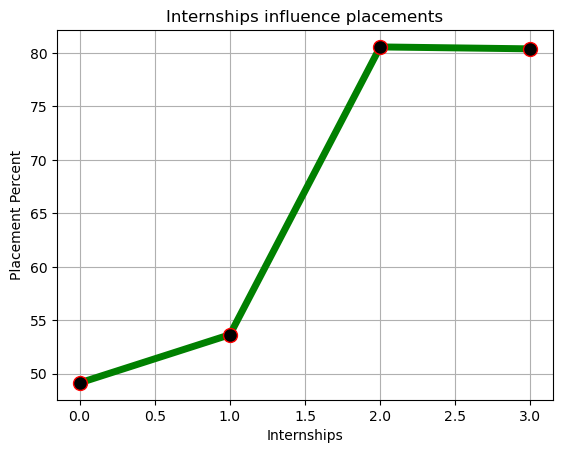

In [30]:
plt.plot(intern_place.index,intern_place['PlacedOrNot'],marker = '.',
         markerfacecolor = 'black',markeredgecolor = 'red',
         markersize = 20,linewidth  = 5,linestyle = 'solid',color = 'green')
plt.title('Internships influence placements')
plt.xlabel('Internships')
plt.ylabel('Placement Percent')
plt.grid()
plt.show()

In [31]:
backlog_percent = college.groupby('HistoryOfBacklogs').agg({'PlacedOrNot':'mean'})

In [32]:
backlog_percent = (backlog_percent * 100).round(2)

In [33]:
backlog_percent.index.tolist()

[0, 1]

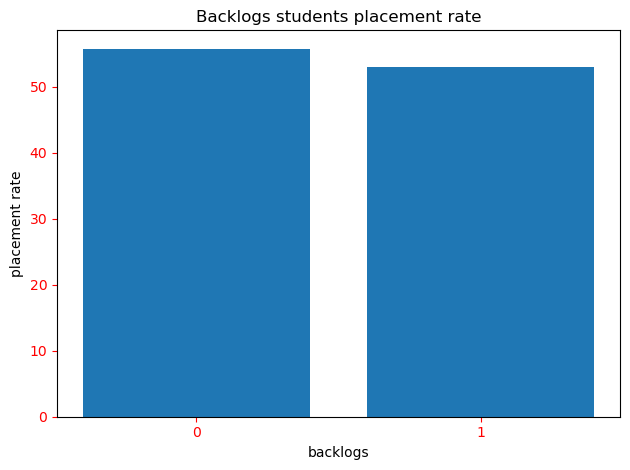

In [34]:
plt.bar(backlog_percent.index,backlog_percent['PlacedOrNot'])
plt.xticks(backlog_percent.index)
plt.tick_params(axis ='both',colors = 'red')
plt.title('Backlogs students placement rate')
plt.xlabel('backlogs')
plt.ylabel('placement rate')
plt.tight_layout()
plt.show()

In [35]:
college.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [37]:
gender_placerate = college.groupby('Gender').agg({'PlacedOrNot':'mean'})

In [38]:
gender_placerate = (gender_placerate * 100).round(2)

In [39]:
print(gender_placerate)

        PlacedOrNot
Gender             
Female        56.01
Male          55.11


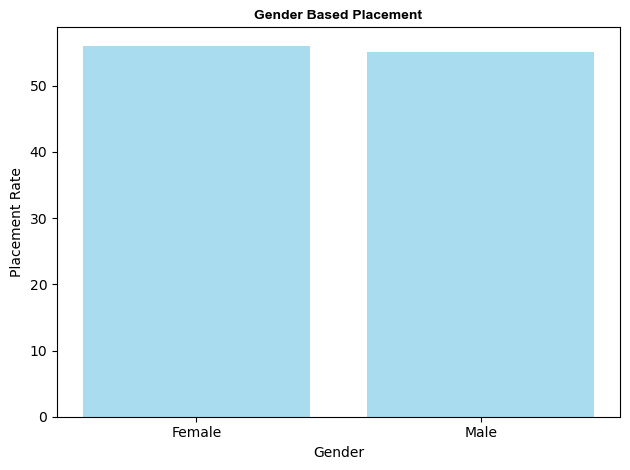

In [43]:
plt.bar(gender_placerate.index,gender_placerate['PlacedOrNot'],color = 'skyblue',alpha = 0.7,)
plt.title('Gender Based Placement',fontsize = 10,fontweight = 'bold',family = 'Arial')
plt.xlabel('Gender')
plt.ylabel('Placement Rate')
plt.tight_layout()
plt.show()


In [44]:
college['Age'].unique()

array([22, 21, 23, 24, 28, 30, 25, 26, 20, 19, 29])

In [46]:
Age_wise = college.groupby('Age').agg({'PlacedOrNot':'mean'})

In [47]:
Age_wise = (Age_wise * 100).round(2)

In [48]:
print(Age_wise)

     PlacedOrNot
Age             
19         58.97
20         53.07
21         56.92
22         50.80
23         43.59
24         79.39
25         75.86
26         74.00
28        100.00
29        100.00
30        100.00


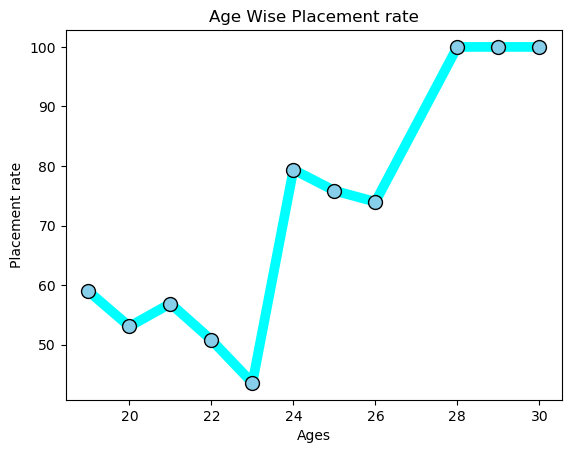

In [51]:
plt.plot(Age_wise.index,Age_wise['PlacedOrNot'],marker = 'o',mfc = 'skyblue',mec = 'black',ms = 10,linewidth = 7,linestyle = 'solid',color = 'cyan')
plt.title('Age Wise Placement rate')
plt.xlabel('Ages')
plt.ylabel('Placement rate')
plt.show()

In [75]:
college['CGPA_group'] = pd.cut(college['CGPA'],bins =[0,6,7,8,9,10],labels = ['0-6','6-7','7-8','8-9','9-10'])

In [76]:
college['Internships_newvalues'] = college['Internships'].apply(
    lambda x: 1 if x > 1 else 0
)

In [78]:
college.groupby(['CGPA_group','Internships_newvalues','HistoryOfBacklogs']).agg({'PlacedOrNot':'mean'})*100

C:\Users\selvi\AppData\Local\Temp\ipykernel_8092\1368658319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  college.groupby(['CGPA_group','Internships_newvalues','HistoryOfBacklogs']).agg({'PlacedOrNot':'mean'})*100


PlacedOrNot
CGPA_group Internships_newvalues HistoryOfBacklogs             
0-6        0                     0                    22.307692
                                 1                    22.839506
           1                     0                    90.196078
                                 1                    18.750000
6-7        0                     0                    24.215247
                                 1                    26.797386
           1                     0                    63.366337
                                 1                    45.454545
7-8        0                     0                   100.000000
                                 1                   100.000000
           1                     0                   100.000000
                                 1                   100.000000
8-9        0                     0                   100.000000
                                 1                   100.000000
           1                     0                   100.000000
                                 1                   100.000000
9-10       0                     0                          NaN
                                 1                          NaN
           1                     0                          NaN
                                 1                          NaN

<Figure size 640x480 with 0 Axes>

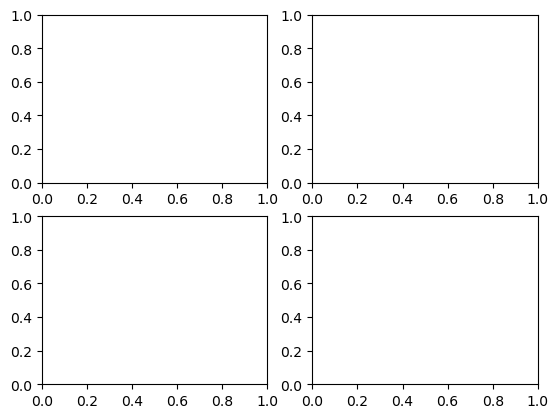

In [ ]:
plt.figure()
figure , axes = plt.subplots(2,2)

axes[0,0]
plt.tight_layout()
plt.show()
